## Análisis y comparación de modelos predictivos de abandono escolar

## carga de datos

In [1]:
import pandas as pd
df = pd.read_excel("encuesta.xlsx")

In [2]:
df.head()

,ID,Hora de inicio,Hora de finalización,Correo electrónico,Nombre,Total de puntos,Comentarios del cuestionario,Hora de la última modificación,Facultad a la que perteneces,Puntos: Facultad a la que perteneces,...,Comentarios: ¿Has tenido alguna experiencia negativa con algún alumno en los últimos dos semestres?,¿Te sientes satisfecho con los servicios de la UANL?,Puntos: ¿Te sientes satisfecho con los servicios de la UANL?,Comentarios: ¿Te sientes satisfecho con los servicios de la UANL?,¿Has considerado dar de baja la carrera que estás estudiando?,Comentarios: ¿Has considerado dar de baja la carrera que estás estudiando?,Puntos: ¿Has considerado dar de baja la carrera que estás estudiando?,¿Algún comentario que desees agregar? (opcional),Comentarios: ¿Algún comentario que desees agregar? (opcional),Puntos: ¿Algún comentario que desees agregar? (opcional)
0,38,2026-05-08 13:23:10,2026-05-08 13:28:51,anonymous,NaN,NaN,NaN,NaN,Odontologia,NaN,...,NaN,Si,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
1,19,2026-05-07 19:27:38,2026-05-07 19:29:58,anonymous,NaN,NaN,NaN,NaN,Derecho y criminologia,NaN,...,NaN,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
2,80,2026-05-09 18:04:02,2026-05-09 18:08:15,anonymous,NaN,NaN,NaN,NaN,Ciencias biologicas,NaN,...,NaN,No,NaN,NaN,No,NaN,NaN,Sin comentarios,NaN,NaN
3,48,2026-05-09 09:02:04,2026-05-09 09:06:11,anonymous,NaN,NaN,NaN,NaN,Arquitectura,NaN,...,NaN,Si,NaN,NaN,Si,NaN,NaN,NaN,NaN,NaN
4,1,2026-05-06 21:42:59,2026-05-06 21:46:07,anonymous,NaN,NaN,NaN,NaN,Ciencias fisico matematicas,NaN,...,NaN,No,NaN,NaN,Si,NaN,NaN,NaN,NaN,NaN


## preprocesamiento de datos

In [3]:
# ELminiar columnas agregadas por forms sin valor ninguno
data = df.dropna(axis=1)
data.head()

,ID,Hora de inicio,Hora de finalización,Correo electrónico,Facultad a la que perteneces,¿Cuál es tu edad?,¿Con qué género te identificas?,¿Cuántos años llevas en la carrera?,¿A qué edad entraste a tu carrera?,¿Por qué motivo elegiste tu carrera?,...,¿A qué clase económica perteneces?,¿Participas en algún club o actividad extracurricular?,¿Cuentas con apoyo económico de tu familia?,¿Cuántas horas de sueño haces?,¿Cómo describirías tu nivel de estrés?,¿Has tenido apoyo psicológico o has pensado en conseguirlo?,¿Has tenido alguna mala experiencia con profesores en los últimos dos semestres?,¿Has tenido alguna experiencia negativa con algún alumno en los últimos dos semestres?,¿Te sientes satisfecho con los servicios de la UANL?,¿Has considerado dar de baja la carrera que estás estudiando?
0,38,2026-05-08 13:23:10,2026-05-08 13:28:51,anonymous,Odontologia,18,Femenino,1,17,Por interes personal,...,Media-baja,Si,No,5,Medio-alto,Si,No,No,Si,No
1,19,2026-05-07 19:27:38,2026-05-07 19:29:58,anonymous,Derecho y criminologia,22,Femenino,4,18,Por interes personal,...,Alta-media,No,Si,7,Alto,Si,Si,No,No,No
2,80,2026-05-09 18:04:02,2026-05-09 18:08:15,anonymous,Ciencias biologicas,18,Femenino,2,17,Por interes personal,...,Media,Si,Si,4,Medio-alto,Si,Si,Si,No,No
3,48,2026-05-09 09:02:04,2026-05-09 09:06:11,anonymous,Arquitectura,20,Otro,3,17,Recomendaciones de gente cercana,...,Media-baja,No,Si,5,Alto,No,Si,Si,Si,Si
4,1,2026-05-06 21:42:59,2026-05-06 21:46:07,anonymous,Ciencias fisico matematicas,18,No Binario,1,17,No tuve eleccion,...,Alta,Si,Si,6,Alto,Si,Si,Si,No,Si


In [4]:
# Eliminar datos de respuesta de forms
columns_to_drop = ['ID', 'Hora de inicio', 'Hora de finalización', 'Correo electrónico']
data = data.drop(columns=columns_to_drop)
data.head()

,Facultad a la que perteneces,¿Cuál es tu edad?,¿Con qué género te identificas?,¿Cuántos años llevas en la carrera?,¿A qué edad entraste a tu carrera?,¿Por qué motivo elegiste tu carrera?,¿Eres foraneo?,¿En cuál municipio vives o te alojas?,¿Cuanto tiempo sueles hacer de traslado a la facultad?,¿Qué medio de transporte sueles usar para llegar a tu facultad?,...,¿A qué clase económica perteneces?,¿Participas en algún club o actividad extracurricular?,¿Cuentas con apoyo económico de tu familia?,¿Cuántas horas de sueño haces?,¿Cómo describirías tu nivel de estrés?,¿Has tenido apoyo psicológico o has pensado en conseguirlo?,¿Has tenido alguna mala experiencia con profesores en los últimos dos semestres?,¿Has tenido alguna experiencia negativa con algún alumno en los últimos dos semestres?,¿Te sientes satisfecho con los servicios de la UANL?,¿Has considerado dar de baja la carrera que estás estudiando?
0,Odontologia,18,Femenino,1,17,Por interes personal,no,Apodaca,Una hora y treinta minutos,Transporte publico,...,Media-baja,Si,No,5,Medio-alto,Si,No,No,Si,No
1,Derecho y criminologia,22,Femenino,4,18,Por interes personal,si,Linares,"Soy del campus Linares, aprox 10 minutos",Auto propio,...,Alta-media,No,Si,7,Alto,Si,Si,No,No,No
2,Ciencias biologicas,18,Femenino,2,17,Por interes personal,no,Monterrey,Media hora a una hora,Me llevan familiares / amigos,...,Media,Si,Si,4,Medio-alto,Si,Si,Si,No,No
3,Arquitectura,20,Otro,3,17,Recomendaciones de gente cercana,no,Santa Catarina,Media hora a 1 hora (con mucho tráfico,Me llevan familiares / amigos,...,Media-baja,No,Si,5,Alto,No,Si,Si,Si,Si
4,Ciencias fisico matematicas,18,No Binario,1,17,No tuve eleccion,no,General Escobedo,Media hora,Transporte publico,...,Alta,Si,Si,6,Alto,Si,Si,Si,No,Si


In [5]:
# Estandarizar los nombres de los municipios
municipio = data['¿En cuál municipio vives o te alojas?']

municipio = municipio.str.lower()

municipio = municipio.str.rstrip()
municipio = municipio.str.replace('á', 'a')
municipio = municipio.str.replace('é', 'e')
municipio = municipio.str.replace('í', 'i')
municipio = municipio.str.replace('ó', 'o')
municipio = municipio.str.replace('ú', 'u')

municipio.unique()

array(['apodaca', 'linares', 'monterrey', 'santa catarina',
       'general escobedo', 'juarez', 'guadalupe', 'san nicolas',
       'san pedro garza garcia', 'san nicolas de los garza', 'escobedo',
       'cadereyta', 'san pedro', 'mo terrey', 'marin', 'garcia',
       'lampazos de naranjo', 'cienega de flores', 'cadereyta jimenez',
       'general zuazua', 'el carmen', 'guadalupe centro', 'escobello',
       'gral escobedo'], dtype=object)

In [6]:
municipios_nl = {
    "abasolo": "abasolo",
    "agualeguas": "agualeguas",
    "los aldamas": "los aldamas",
    "allende": "allende",
    "anahuac": "anahuac",
    "apodaca": "apodaca",
    "aramberri": "aramberri",
    "bustamante": "bustamante",
    "cadereyta": "cadereyta",
    "cadereyta jimenez": "cadereyta",
    "carmen": "carmen",
    "cerralvo": "cerralvo",
    "cienega de flores": "cienega de flores",
    "china": "china",
    "doctor arroyo": "doctor arroyo",
    "doctor coss": "doctor coss",
    "doctor gonzalez": "doctor gonzalez",
    "galeana": "galeana",
    "garcia": "garcia",
    "san pedro garza garcia": "san pedro",
    "san pedro": "san pedro",
    "general bravo": "general bravo",
    "general escobedo": "general escobedo",
    "gral escobedo": "general escobedo",
    "escobello": "general escobedo",
    "escobedo": "general escobedo",
    "general teran": "general teran",
    "general trevino": "general trevino",
    "general zuazua": "general zuazua",
    "guadalupe": "guadalupe",
    "guadalupe centro": "guadalupe",
    "los herreras": "los herreras",
    "higueras": "higueras",
    "hualahuises": "hualahuises",
    "iturbide": "iturbide",
    "juarez": "juarez",
    "lampazos de naranjo": "lampazos de naranjo",
    "linares": "linares",
    "marin": "marin",
    "melchor ocampo": "melchor ocampo",
    "mier y noriega": "mier y noriega",
    "mina": "mina",
    "montemorelos": "montemorelos",
    "mo terrey": "monterrey",
    "monterrey": "monterrey",
    "paras": "paras",
    "pesqueria": "pesqueria",
    "los ramones": "los ramones",
    "rayones": "rayones",
    "sabinas hidalgo": "sabinas hidalgo",
    "salinas victoria": "salinas victoria",
    "san nicolas de los garza": "san nicolas",
    "san nicolas": "san nicolas",
    "hidalgo": "hidalgo",
    "santa catarina": "santa catarina",
    "santiago": "santiago",
}

municipio = municipio.replace(municipios_nl)
municipio.unique()
data['¿En cuál municipio vives o te alojas?'] = municipio

In [7]:
import re
import pandas as pd

def convertir_tiempo_a_minutos(valor):
    if pd.isna(valor):
        return None

    texto = str(valor).lower().strip()
    if not texto:
        return None

    texto = texto.replace("aproximadamente", " ")
    texto = texto.replace("aprox", " ")
    texto = texto.replace("en el mejor de los casos", " ")
    texto = texto.replace("oh", " o ")
    texto = re.sub(r"\buna\b", "1", texto)
    texto = re.sub(r"(\d+(?:[.,]\d+)?)\s*(?:hrs?|hr|h)\b", r"\1 hora", texto)
    texto = re.sub(r"(\d+(?:[.,]\d+)?)\s*(?:mins?|min|m)\b", r"\1 minuto", texto)
    texto = re.sub(r"\bhoras?\b", "hora", texto)
    texto = re.sub(r"\bminutos?\b", "minuto", texto)
    texto = texto.replace(",", ".")

    minutos = []

    def extraer(patron, transformacion):
        nonlocal texto, minutos
        while True:
            coincidencia = re.search(patron, texto)
            if not coincidencia:
                break
            resultado = transformacion(coincidencia)
            if isinstance(resultado, (list, tuple, set)):
                minutos.extend(resultado)
            else:
                minutos.append(resultado)
            texto = texto[:coincidencia.start()] + " " + texto[coincidencia.end():]

    extraer(r"(\d+(?:[.,]\d+)?)\s*hora\s*y\s*(\d{1,2})(?:\s*minuto)?\b", lambda m: float(m.group(1)) * 60 + float(m.group(2)))
    extraer(r"(\d+(?:[.,]\d+)?)\s*hora\s+(\d{1,2})(?:\s*minuto)?\b", lambda m: float(m.group(1)) * 60 + float(m.group(2)))
    extraer(r"(\d+(?:[.,]\d+)?)\s*hora\s*y\s+media\b", lambda m: float(m.group(1)) * 60 + 30)
    extraer(r"\bhora\s+y\s+media\b", lambda m: 90)
    extraer(r"\bmedia\s+hora\b", lambda m: 30)
    extraer(r"(\d+)\s+y\s+media\b", lambda m: int(m.group(1)) * 60 + 30)
    extraer(r"(\d+)\s*[:.]\s*(\d{1,2})\b", lambda m: int(m.group(1)) * 60 + int(m.group(2)))
    extraer(r"(\d+(?:[.,]\d+)?)\s*hora\s*(?:a|o|-|/)\s*(\d+(?:[.,]\d+)?)\s*hora\b", lambda m: [float(m.group(1)) * 60, float(m.group(2)) * 60])
    extraer(r"(\d+(?:[.,]\d+)?)\s*(?:a|o|-|/)\s*(\d+(?:[.,]\d+)?)\s*minuto\b", lambda m: [float(m.group(1)), float(m.group(2))])
    extraer(r"(\d+(?:[.,]\d+)?)\s*hora\s*(?:a|o|-|/)\s*(\d+(?:[.,]\d+)?)\s*minuto\b", lambda m: [float(m.group(1)) * 60, float(m.group(2))])
    extraer(r"(\d+(?:[.,]\d+)?)\s*minuto\s*(?:a|o|-|/)\s*(\d+(?:[.,]\d+)?)\s*hora\b", lambda m: [float(m.group(1)), float(m.group(2)) * 60])
    extraer(r"(\d+)\s*[:.]\s*(\d{1,2})\s*(?:a|o|-|/)\s*(\d+(?:[.,]\d+)?)\s*hora\b", lambda m: [int(m.group(1)) * 60 + int(m.group(2)), float(m.group(3)) * 60])
    extraer(r"(\d+(?:[.,]\d+)?)\s*hora\b", lambda m: float(m.group(1)) * 60)
    extraer(r"(\d+(?:[.,]\d+)?)\s*minuto\b", lambda m: float(m.group(1)))

    numeros = [int(n) for n in re.findall(r"\b\d+\b", texto)]
    if numeros:
        if len(numeros) == 1:
            n = numeros[0]
            minutos.append(n * 60 if n <= 10 else n)
        else:
            minutos.extend([n * 60 if n <= 10 else n for n in numeros])

    if not minutos:
        return None

    return round(sum(minutos) / len(minutos))


distintos = data[["¿Cuanto tiempo sueles hacer de traslado a la facultad?"]].drop_duplicates().copy()
distintos["minutos"] = distintos["¿Cuanto tiempo sueles hacer de traslado a la facultad?"].apply(convertir_tiempo_a_minutos)
distintos

,¿Cuanto tiempo sueles hacer de traslado a la facultad?,minutos
0,Una hora y treinta minutos,60
1,"Soy del campus Linares, aprox 10 minutos",10
2,Media hora a una hora,45
3,Media hora a 1 hora (con mucho tráfico,45
4,Media hora,30
...,...,...
127,1 hora a 2 horas,90
128,1 hora 40 minutos,100
129,1 hora,60
133,1 hora,60


In [8]:
#for index, row in distintos.iterrows():
#    print(f"Original: {row['¿Cuanto tiempo sueles hacer de traslado a la facultad?']} -> Minutos: {row['minutos']}")

In [9]:
#imprimir todos los datos de distintos
#for index, row in distintos.iterrows():
#    print(f"Original: {row['¿Cuanto tiempo sueles hacer de traslado a la facultad?']} -> Minutos: {row['minutos']}")

In [10]:
#Cambiar los datos de la columna original por los minutos
data['¿Cuanto tiempo sueles hacer de traslado a la facultad?'] = data['¿Cuanto tiempo sueles hacer de traslado a la facultad?'].apply(convertir_tiempo_a_minutos)
data.head()

,Facultad a la que perteneces,¿Cuál es tu edad?,¿Con qué género te identificas?,¿Cuántos años llevas en la carrera?,¿A qué edad entraste a tu carrera?,¿Por qué motivo elegiste tu carrera?,¿Eres foraneo?,¿En cuál municipio vives o te alojas?,¿Cuanto tiempo sueles hacer de traslado a la facultad?,¿Qué medio de transporte sueles usar para llegar a tu facultad?,...,¿A qué clase económica perteneces?,¿Participas en algún club o actividad extracurricular?,¿Cuentas con apoyo económico de tu familia?,¿Cuántas horas de sueño haces?,¿Cómo describirías tu nivel de estrés?,¿Has tenido apoyo psicológico o has pensado en conseguirlo?,¿Has tenido alguna mala experiencia con profesores en los últimos dos semestres?,¿Has tenido alguna experiencia negativa con algún alumno en los últimos dos semestres?,¿Te sientes satisfecho con los servicios de la UANL?,¿Has considerado dar de baja la carrera que estás estudiando?
0,Odontologia,18,Femenino,1,17,Por interes personal,no,apodaca,60,Transporte publico,...,Media-baja,Si,No,5,Medio-alto,Si,No,No,Si,No
1,Derecho y criminologia,22,Femenino,4,18,Por interes personal,si,linares,10,Auto propio,...,Alta-media,No,Si,7,Alto,Si,Si,No,No,No
2,Ciencias biologicas,18,Femenino,2,17,Por interes personal,no,monterrey,45,Me llevan familiares / amigos,...,Media,Si,Si,4,Medio-alto,Si,Si,Si,No,No
3,Arquitectura,20,Otro,3,17,Recomendaciones de gente cercana,no,santa catarina,45,Me llevan familiares / amigos,...,Media-baja,No,Si,5,Alto,No,Si,Si,Si,Si
4,Ciencias fisico matematicas,18,No Binario,1,17,No tuve eleccion,no,general escobedo,30,Transporte publico,...,Alta,Si,Si,6,Alto,Si,Si,Si,No,Si


## Análisis exploratorio
### Tras limpieza de datos

In [11]:
#variables categoricas
categoricas = data.select_dtypes(include=['object']).columns
categoricas

Index(['Facultad a la que perteneces ', '¿Con qué género te identificas?',
       '¿Por qué motivo elegiste tu carrera?', '¿Eres foraneo?',
       '¿En cuál municipio vives o te alojas?',
       '¿Qué medio de transporte sueles usar para llegar a tu facultad?',
       '¿Cuál es tu promedio en la carrera?',
       '¿Cuál fue tu calificación en la preparatoria?', '¿Tienes beca activa?',
       '¿Reprobaste alguna materia en preparatoria, secundaria o primaria?',
       '¿estuviste cursando terceras o quintas en los últimos dos semestres?',
       '¿Se te facilita comprender los temas que se te estan enseñando?',
       '¿Has cambiado anteriormente de carrera?', '¿Trabajas actualmente?',
       '¿Tienes o has tenido algún trabajo relacionado a tu carrera?',
       '¿A qué clase económica perteneces?',
       '¿Participas en algún club o actividad extracurricular?',
       '¿Cuentas con apoyo económico de tu familia?',
       '¿Cómo describirías tu nivel de estrés?',
       '¿Has tenido ap

In [12]:
#variable numericas
numericas = data.select_dtypes(include=['number']).columns
numericas

Index(['¿Cuál es tu edad?', '¿Cuántos años llevas en la carrera? ',
       '¿A qué edad entraste a tu carrera?',
       '¿Cuanto tiempo sueles hacer de traslado a la facultad?',
       '¿Cuántas materias has reprobado en la carrera?',
       '¿Cuántas horas al día sueles dedicarle a los estudios?',
       'del 1 al 5. ¿Cómo calificarías el desempeño promedio de tus profesores?',
       '¿Cuántas horas de sueño haces?'],
      dtype='object')

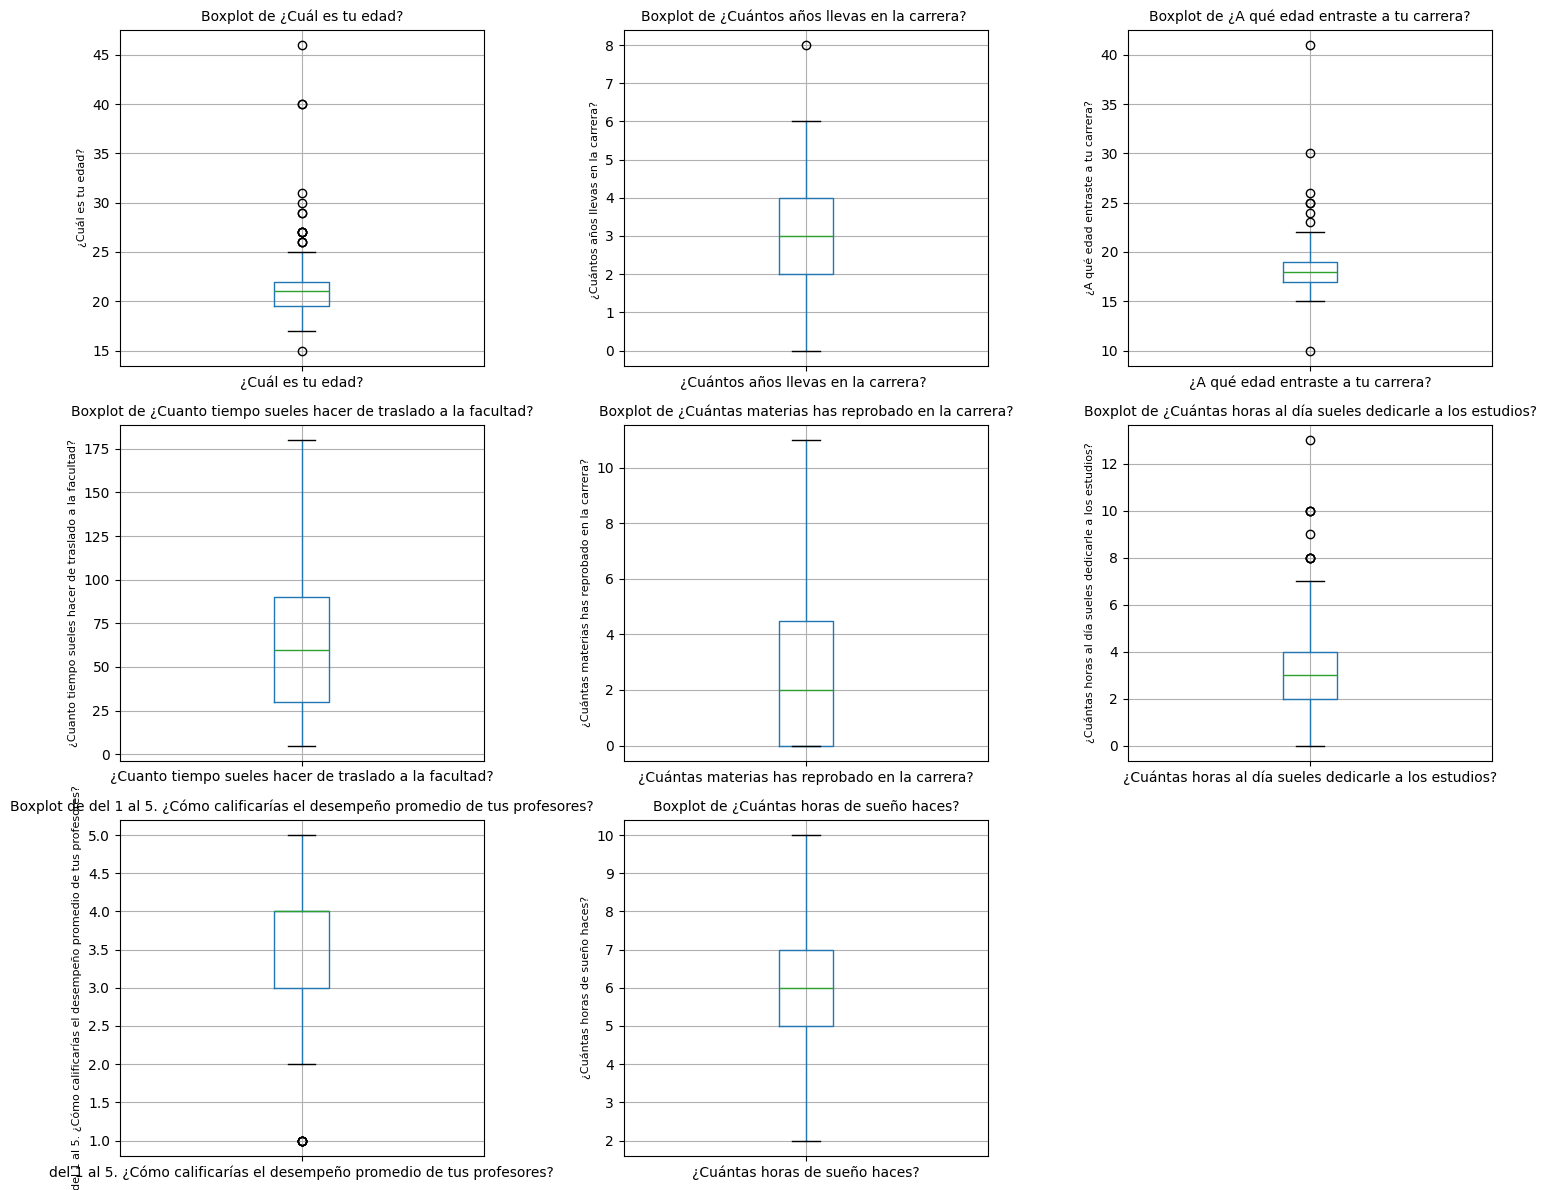

In [13]:
#boxplot de cada variable numerica en un subplot
import matplotlib.pyplot as plt
import numpy as np

# Crear grid de subplots
n_vars = len(numericas)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # Convertir a 1D para iteración fácil

for idx, col in enumerate(numericas):
    data.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(f"Boxplot de {col}", fontsize=10)
    axes[idx].set_ylabel(col, fontsize=8)
    

# Ocultar ejes vacíos
for idx in range(len(numericas), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

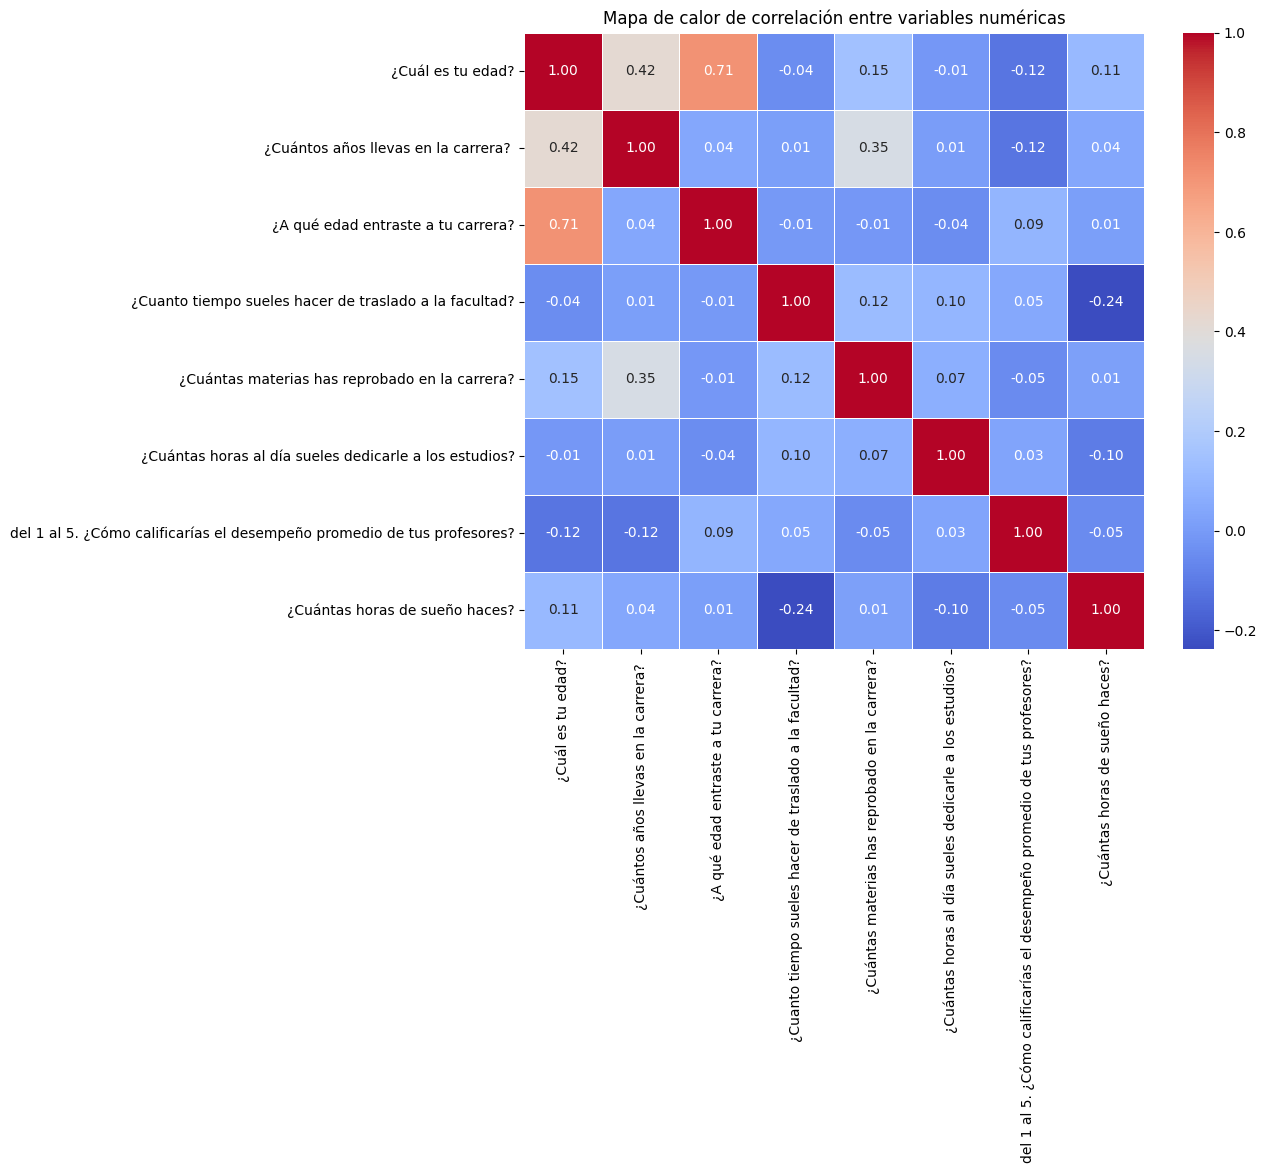

In [14]:
# heatmap de correlacion entre variables numericas
import seaborn as sns
plt.figure(figsize=(10, 8))
correlacion = data[numericas].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de calor de correlación entre variables numéricas")
plt.show()

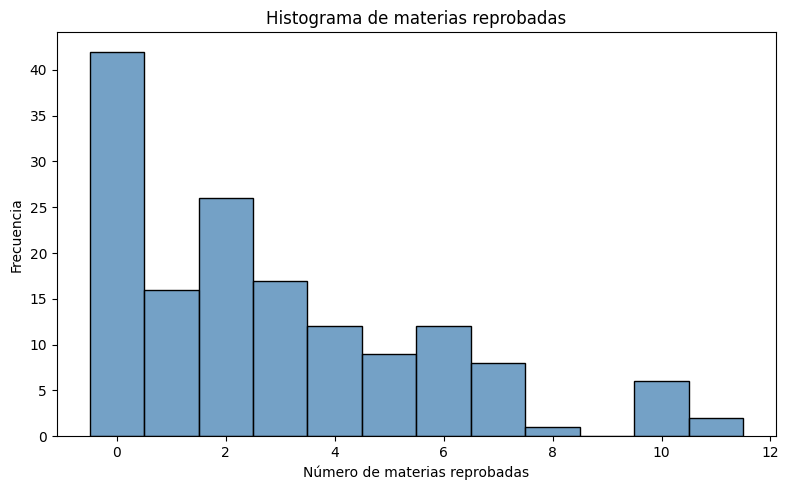

In [15]:
# Histograma de materias reprobadas
import matplotlib.pyplot as plt
import seaborn as sns

col_materias = '¿Cuántas materias has reprobado en la carrera?'

plt.figure(figsize=(8, 5))
sns.histplot(
    data=data,
    x=col_materias,
    bins=range(int(data[col_materias].min()), int(data[col_materias].max()) + 2),
    discrete=True,
    color='steelblue',
    edgecolor='black'
)
plt.title('Histograma de materias reprobadas')
plt.xlabel('Número de materias reprobadas')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

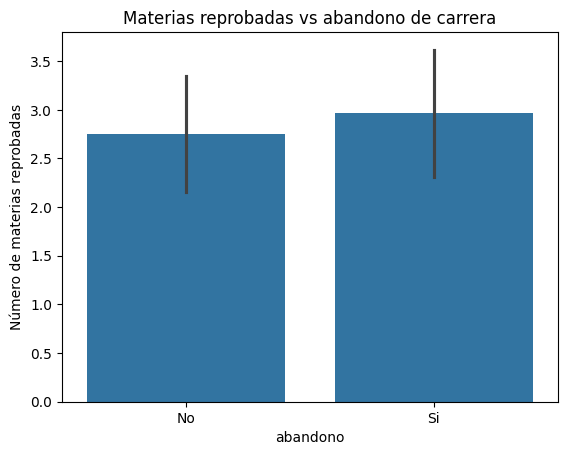

In [16]:
#barplot de materias reprobadas vs target
sns.barplot(y='¿Cuántas materias has reprobado en la carrera?', x='¿Has considerado dar de baja la carrera que estás estudiando?', data=data)
plt.title("Materias reprobadas vs abandono de carrera")
plt.ylabel("Número de materias reprobadas")
plt.xlabel("abandono")
plt.show()

### Entrenamiento del modelo

In [17]:
# Separación de target y features
x = data.drop(columns=['¿Has considerado dar de baja la carrera que estás estudiando?'])
y = data['¿Has considerado dar de baja la carrera que estás estudiando?'].map({'Si': 1, 'No': 0})

# cambiar columnas de las caracteristicas de si y no a 1 y 0 respectivamente
lista_columnas_si_no = [col for col in x.columns if x[col].dtype == 'object' and set(x[col].dropna().unique()).issubset({'Si', 'No'}) or set(x[col].dropna().unique()).issubset({'si', 'no'})]
for col in lista_columnas_si_no:
    x[col] = x[col].map({'Si': 1, 'No': 0, 'si': 1, 'no': 0}).fillna(0)

x.head()

,Facultad a la que perteneces,¿Cuál es tu edad?,¿Con qué género te identificas?,¿Cuántos años llevas en la carrera?,¿A qué edad entraste a tu carrera?,¿Por qué motivo elegiste tu carrera?,¿Eres foraneo?,¿En cuál municipio vives o te alojas?,¿Cuanto tiempo sueles hacer de traslado a la facultad?,¿Qué medio de transporte sueles usar para llegar a tu facultad?,...,¿Tienes o has tenido algún trabajo relacionado a tu carrera?,¿A qué clase económica perteneces?,¿Participas en algún club o actividad extracurricular?,¿Cuentas con apoyo económico de tu familia?,¿Cuántas horas de sueño haces?,¿Cómo describirías tu nivel de estrés?,¿Has tenido apoyo psicológico o has pensado en conseguirlo?,¿Has tenido alguna mala experiencia con profesores en los últimos dos semestres?,¿Has tenido alguna experiencia negativa con algún alumno en los últimos dos semestres?,¿Te sientes satisfecho con los servicios de la UANL?
0,Odontologia,18,Femenino,1,17,Por interes personal,0,apodaca,60,Transporte publico,...,0,Media-baja,1,0,5,Medio-alto,1,0,0,1
1,Derecho y criminologia,22,Femenino,4,18,Por interes personal,1,linares,10,Auto propio,...,0,Alta-media,0,1,7,Alto,1,1,0,0
2,Ciencias biologicas,18,Femenino,2,17,Por interes personal,0,monterrey,45,Me llevan familiares / amigos,...,0,Media,1,1,4,Medio-alto,1,1,1,0
3,Arquitectura,20,Otro,3,17,Recomendaciones de gente cercana,0,santa catarina,45,Me llevan familiares / amigos,...,0,Media-baja,0,1,5,Alto,0,1,1,1
4,Ciencias fisico matematicas,18,No Binario,1,17,No tuve eleccion,0,general escobedo,30,Transporte publico,...,0,Alta,1,1,6,Alto,1,1,1,0


In [18]:
# Aplicar OHE a las variables categoricas restantes
x_ohe = pd.get_dummies(x, drop_first=True)
x_ohe.head()

,¿Cuál es tu edad?,¿Cuántos años llevas en la carrera?,¿A qué edad entraste a tu carrera?,¿Eres foraneo?,¿Cuanto tiempo sueles hacer de traslado a la facultad?,¿Tienes beca activa?,¿Cuántas materias has reprobado en la carrera?,"¿Reprobaste alguna materia en preparatoria, secundaria o primaria?",¿estuviste cursando terceras o quintas en los últimos dos semestres?,¿Cuántas horas al día sueles dedicarle a los estudios?,...,¿Cuál fue tu calificación en la preparatoria?_80-90,¿Cuál fue tu calificación en la preparatoria?_90-100,¿A qué clase económica perteneces?_Alta-media,¿A qué clase económica perteneces?_Baja,¿A qué clase económica perteneces?_Media-baja,¿A qué clase económica perteneces?_Media,¿Cómo describirías tu nivel de estrés?_Bajo,¿Cómo describirías tu nivel de estrés?_Medio,¿Cómo describirías tu nivel de estrés?_Medio-alto,¿Cómo describirías tu nivel de estrés?_Medio-bajo
0,18,1,17,0,60,0,0,0,0,3.0,...,True,False,False,False,True,False,False,False,True,False
1,22,4,18,1,10,0,4,1,0,2.0,...,True,False,True,False,False,False,False,False,False,False
2,18,2,17,0,45,0,2,0,1,3.0,...,True,False,False,False,False,True,False,False,True,False
3,20,3,17,0,45,1,3,0,0,6.0,...,False,True,False,False,True,False,False,False,False,False
4,18,1,17,0,30,0,3,1,1,3.0,...,True,False,False,False,False,False,False,False,False,False


In [19]:
#dividir en train y test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_ohe, y, test_size=0.2, random_state=42)

In [20]:
# modelo de random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [21]:
# metricas del modelo
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = rf.predict(x_test)
clas_rep = classification_report(y_test, y_pred)
matriz = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print("Reporte de clasificación:\n", clas_rep)
print("Matriz de confusión:\n", matriz)
print("Precisión:\n", accuracy)

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.52      0.79      0.63        14
           1       0.70      0.41      0.52        17

    accuracy                           0.58        31
   macro avg       0.61      0.60      0.57        31
weighted avg       0.62      0.58      0.57        31

Matriz de confusión:
 [[11  3]
 [10  7]]
Precisión:
 0.5806451612903226


## Modelo con reduccion de dimensionalidad

### 1 opcion: manualmente eliminar columnas menos relevantes

In [22]:
# normalizar los nombres de las columnas
x.columns = x.columns.str.replace('\xa0', ' ', regex=False).str.strip()

# lista de columnas a eliminar
cols = ['Facultad a la que perteneces', '¿Con qué género te identificas?',
        '¿En cuál municipio vives o te alojas?', '¿Cuál es tu edad?',
        '¿Cuanto tiempo sueles hacer de traslado a la facultad?',
        '¿Qué medio de transporte sueles usar para llegar a tu facultad?']

x_nuevo = x.copy()
x_nuevo.drop(columns=cols, errors='ignore', inplace=True)

# aplicar OHE a las variables categoricas restantes
x_nuevo_ohe = pd.get_dummies(x_nuevo, drop_first=True)
x_nuevo_ohe.head()

,¿Cuántos años llevas en la carrera?,¿A qué edad entraste a tu carrera?,¿Eres foraneo?,¿Tienes beca activa?,¿Cuántas materias has reprobado en la carrera?,"¿Reprobaste alguna materia en preparatoria, secundaria o primaria?",¿estuviste cursando terceras o quintas en los últimos dos semestres?,¿Cuántas horas al día sueles dedicarle a los estudios?,¿Se te facilita comprender los temas que se te estan enseñando?,del 1 al 5. ¿Cómo calificarías el desempeño promedio de tus profesores?,...,¿Cuál fue tu calificación en la preparatoria?_80-90,¿Cuál fue tu calificación en la preparatoria?_90-100,¿A qué clase económica perteneces?_Alta-media,¿A qué clase económica perteneces?_Baja,¿A qué clase económica perteneces?_Media-baja,¿A qué clase económica perteneces?_Media,¿Cómo describirías tu nivel de estrés?_Bajo,¿Cómo describirías tu nivel de estrés?_Medio,¿Cómo describirías tu nivel de estrés?_Medio-alto,¿Cómo describirías tu nivel de estrés?_Medio-bajo
0,1,17,0,0,0,0,0,3.0,1,4,...,True,False,False,False,True,False,False,False,True,False
1,4,18,1,0,4,1,0,2.0,1,5,...,True,False,True,False,False,False,False,False,False,False
2,2,17,0,0,2,0,1,3.0,0,3,...,True,False,False,False,False,True,False,False,True,False
3,3,17,0,1,3,0,0,6.0,0,4,...,False,True,False,False,True,False,False,False,False,False
4,1,17,0,0,3,1,1,3.0,1,1,...,True,False,False,False,False,False,False,False,False,False


In [23]:
# realizar train test split con el nuevo x
from sklearn.model_selection import train_test_split
x_train_nuevo, x_test_nuevo, y_train_nuevo, y_test_nuevo = train_test_split(x_nuevo_ohe, y, test_size=0.2, random_state=42) 

#entrenar modelo de random forest con el nuevo x
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(x_train_nuevo, y_train_nuevo)

# metricas del nuevo modelo
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = rf.predict(x_test_nuevo)
print("Reporte de clasificación:\n", classification_report(y_test_nuevo, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test_nuevo, y_pred))
#print("Precisión:\n", accuracy_score(y_test_nuevo, y_pred))

#comparar presicion de este modelo con el anterior
print (f"\nPrecisión del modelo con todas las características: {accuracy:.4f}")
print (f"Precisión del modelo con características seleccionadas: {accuracy_score(y_test_nuevo, y_pred):.4f}")

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.57      0.86      0.69        14
           1       0.80      0.47      0.59        17

    accuracy                           0.65        31
   macro avg       0.69      0.66      0.64        31
weighted avg       0.70      0.65      0.63        31

Matriz de confusión:
 [[12  2]
 [ 9  8]]

Precisión del modelo con todas las características: 0.5806
Precisión del modelo con características seleccionadas: 0.6452


### 2da opción: extracción de características con RFE

In [ ]:
# RFE: Recursive Feature Elimination
# Es un metodo de selección de características que elimina recursivamente las características
# menos importantes basándose en un modelo estimador. En cada iteración, se ajusta el modelo y se eliminan
# las características con menor importancia hasta que se alcanza el número deseado de características seleccionadas.
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Configuración del estimador y el selector
# Usamos un estado aleatorio fijo para que los resultados sean reproducibles
estimator = RandomForestClassifier(n_estimators=300, random_state=42)

# RFE seleccionará las n mejores variables.
selector = RFE(estimator=estimator, n_features_to_select=15, step=1)

# Creación del Pipeline
rfe_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', selector),
    ('classification', RandomForestClassifier(n_estimators=300, random_state=42))
])

# Entrenamiento
rfe_pipeline.fit(x_train, y_train)

# Predicciones y resultados
y_pred_rfe = rfe_pipeline.predict(x_test)
precision_rfe = accuracy_score(y_test, y_pred_rfe)

print(f"Precisión con RFE: {precision_rfe:.4f}")
print(f"precisión sin RFE: {accuracy:.4f}")
print("\nReporte de clasificación con RFE:")
print(classification_report(y_test, y_pred_rfe))

# imprimir las columnas seleccionadas por RFE
soporte = rfe_pipeline.named_steps['feature_selection'].support_
columnas_finales = x_ohe.columns[soporte]
print(f"\nLas {len(columnas_finales)} variables seleccionadas son:")
print(list(columnas_finales))

Precisión con RFE: 0.6129
precisión sin RFE: 0.5806

Reporte de clasificación con RFE:
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.69      0.53      0.60        17

    accuracy                           0.61        31
   macro avg       0.62      0.62      0.61        31
weighted avg       0.63      0.61      0.61        31


Las 15 variables seleccionadas son:
['¿Cuál es tu edad?', '¿Cuántos años llevas en la carrera?\xa0', '¿A qué edad entraste a tu carrera?', '¿Eres foraneo?', '¿Cuanto tiempo sueles hacer de traslado a la facultad?', '¿Cuántas materias has reprobado en la carrera?', '¿Cuántas horas al día sueles dedicarle a los estudios?', '¿Se te facilita comprender los temas que se te estan enseñando?', 'del 1 al 5. ¿Cómo calificarías el desempeño promedio de tus profesores?', '¿Cuántas horas de sueño haces?', '¿Has tenido alguna mala experiencia con profesores en los últimos dos semestres?', '¿

In [ ]:
import pygad
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# FUNCION FITNESS
def fitness_func(ga_instance, solution, solution_idx):
    # Evitar individuos vacíos (todos los genes en 0)
    if np.sum(solution) == 0:
        return 0.0
    
    # Seleccionar columnas basadas en la solución binaria
    selected_features = x_ohe.columns[solution == 1]
    X_selected = x_ohe[selected_features]
    
    model = RandomForestClassifier(
        n_estimators=200, 
        random_state=42, 
        class_weight='balanced'
    )
    
    # Retornamos la media del F1 Score
    score = cross_val_score(
        model, X_selected, y, cv=5, scoring='f1'
    ).mean()
    
    return score

# CONFIGURACIÓN Y EJECUCIÓN
ga_instance = pygad.GA(
    num_generations=40,
    num_parents_mating=15,       # Mitad de la población para reproducirse
    fitness_func=fitness_func,
    sol_per_pop=30,              # POP_SIZE
    num_genes=x_ohe.shape[1],    # N_FEATURES
    gene_space=[0, 1],           # Valores posibles por gen (binario)
    parent_selection_type="tournament",
    K_tournament=3,              # TOURNAMENT_SIZE
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=5.0,  
    stop_criteria=["reach_1.0"]  # Opcional: para si llega al score perfecto
)

ga_instance.run()

# RESULTADOS
solution, solution_fitness, solution_idx = ga_instance.best_solution()
selected_features = x_ohe.columns[np.array(solution) == 1]

print(f"Mejor F1 Score: {solution_fitness:.4f}")
print(f"Cantidad de features: {len(selected_features)}")
print("Features seleccionadas:", list(selected_features))

Mejor F1 Score: 0.6915
Cantidad de features: 38
Features seleccionadas: ['¿Eres foraneo?', '¿Cuanto tiempo sueles hacer de traslado a la facultad?', '¿Reprobaste alguna materia en preparatoria, secundaria o primaria?', '¿Participas en algún club o actividad extracurricular?', '¿Has tenido alguna mala experiencia con profesores en los últimos dos semestres?', 'Facultad a la que perteneces\xa0_Artes escenicas', 'Facultad a la que perteneces\xa0_Ciencias biologicas', 'Facultad a la que perteneces\xa0_Ciencias de la comunicación', 'Facultad a la que perteneces\xa0_Ciencias de la tierra', 'Facultad a la que perteneces\xa0_Ciencias fisico matematicas', 'Facultad a la que perteneces\xa0_Ciencias politicas', 'Facultad a la que perteneces\xa0_Enfermeria', 'Facultad a la que perteneces\xa0_Musica', 'Facultad a la que perteneces\xa0_Organizacion deportiva', 'Facultad a la que perteneces\xa0_Salud publica y nutricion', 'Facultad a la que perteneces\xa0_Veterinaria', '¿Con qué género te identificas

In [1091]:
data_features = x_ohe[selected_features]
x_train_sel, x_test_sel, y_train_sel, y_test_sel = train_test_split(
    data_features, y, test_size=0.2, random_state=42
)
model_sel = RandomForestClassifier(n_estimators=200, random_state=42)
model_sel.fit(x_train_sel, y_train_sel)
y_pred_sel = model_sel.predict(x_test_sel)
print("\nReporte de clasificación con GA:")
print(classification_report(y_test_sel, y_pred_sel))
print("confusion_matrix con GA:")
print(confusion_matrix(y_test_sel, y_pred_sel))


Reporte de clasificación con GA:
              precision    recall  f1-score   support

           0       0.57      0.86      0.69        14
           1       0.80      0.47      0.59        17

    accuracy                           0.65        31
   macro avg       0.69      0.66      0.64        31
weighted avg       0.70      0.65      0.63        31

confusion_matrix con GA:
[[12  2]
 [ 9  8]]
